In [1]:
import sys
import polars as pl
from hmmlearn import hmm
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import pandas as pd

In [2]:
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, data_utils, plots, strategy_utils

TRAIN_PATH = config.TRAIN_PATH
TEST_PATH = config.TEST_PATH
total_budget_usd = config.TOTAL_BUDGET_USD

# HMM + Bayesian Network Accumulation Strategy

Use a Hidden Markov Model to infer latent market regimes, then apply a Bayesian Network to convert observed evidence (valuation, volatility, price state) into a probability of an accumulation opportunity.

**Data Preparation**
Load BRK on-chain metrics, compute log returns, GARCH conditional volatility, and rolling MVRV features used as HMM inputs.

**HMM Training**
Fit a 3-state Gaussian HMM on [return, GARCH volatility, MVRV z-score, price vs active price]. Assign qualitative regime labels (accumulation / neutral / euphoric) by inspecting per-regime statistics.

**Bayesian Classification**
Discretize continuous features (valuation state, volatility state, active price state) and fit a Discrete Bayesian Network using Maximum Likelihood Estimation. Query the network to compute `P(accumulation_opportunity = "yes")` for each day.

**Accumulation Signal & Backtest**
Convert the Bayesian probability into a daily allocation weight, smooth with a 7-day rolling mean, and backtest `HMMBayesAccumulationStrategy` year-by-year (2018–2023) against MVRV and uniform DCA baselines.

In [3]:
# HMM → latent market regime
# Bayesian Network → probability of accumulation opportunity
# Stacksats strategy → daily DCA multiplier

In [4]:
features = [
    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"
]

In [5]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(features))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [6]:
df = df.to_pandas()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)

date              0.0
active_price      0.0
market_cap        0.0
mvrv              0.0
realized_price    0.0
supply_btc        0.0
price_usd         0.0
dtype: float64

In [7]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

In [8]:
ts = df.copy()
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)

In [9]:
from arch import arch_model

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [10]:
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)

In [11]:
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Fri, Jun 05 2026   Df Residuals:                     2189
Time:                              02:39:51   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [12]:
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility

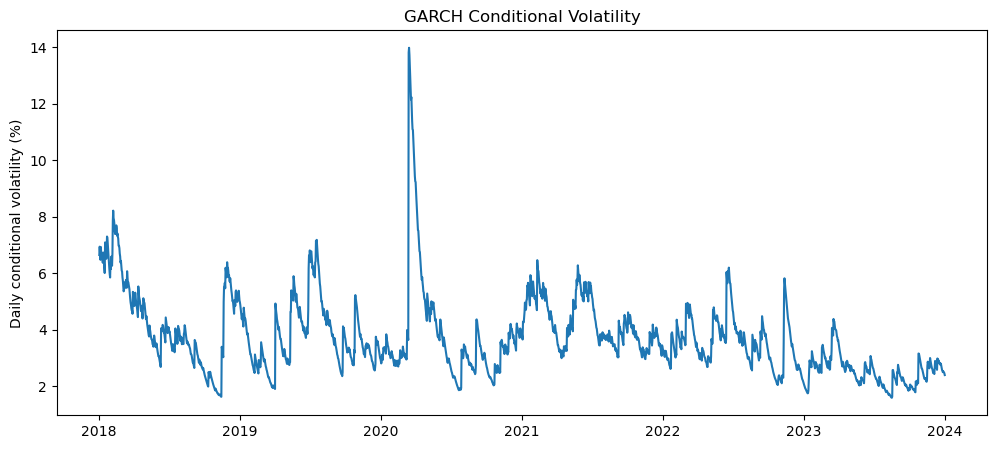

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["garch_volatility"])
plt.title("GARCH Conditional Volatility")
plt.ylabel("Daily conditional volatility (%)")
plt.show()

In [14]:
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()

In [15]:
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)

In [16]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [17]:
hmm_features["regime"] = hmm.predict(X)

In [18]:
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

In [19]:
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]

In [20]:
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime","price_vs_active"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

In [21]:
regime_summary = (
    hmm_features
    .groupby("regime")
    .mean()
)

regime_summary

,return,volatility,mvrv_z,price_vs_active,regime_prob_0,regime_prob_1,regime_prob_2
regime,,,,,,,
0,0.006480,5.216007,1.379440,2.420407,0.979914,0.002754,0.017332
1,-0.001964,3.954175,-0.617299,2.312177,0.000783,0.997434,0.001783
2,0.001105,2.880455,0.251039,1.248468,0.005578,0.000239,0.994183


In [22]:
plot_df.columns.tolist()

['active_price',
 'market_cap',
 'mvrv',
 'realized_price',
 'supply_btc',
 'price_usd',
 'mvrv_deviation',
 'mvrv_z_rolling',
 'btc_log_return',
 'btc_return_pct',
 'garch_volatility',
 'hmm_regime',
 'price_vs_active',
 'regime_prob_0',
 'regime_prob_1',
 'regime_prob_2']

In [23]:
# MVRV tells us valuation.
# GARCH volatility tells us stress.
# Price vs active price tells us participant profitability.
# HMM regime tells us latent market state.

In [24]:
bn_df = plot_df.copy()

bn_df["valuation_state"] = pd.cut(
    bn_df["mvrv_z_rolling"],
    bins=[-np.inf, -1.0, 1.0, np.inf],
    labels=["cheap", "neutral", "expensive"]
)

bn_df["volatility_state"] = pd.cut(
    bn_df["garch_volatility"].rank(pct=True),
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"]
)

bn_df["active_price_state"] = pd.cut(
    bn_df["price_vs_active"],
    bins=[-np.inf, -0.05, 0.10, np.inf],
    labels=["below_active", "near_active", "above_active"]
)

bn_df["regime_state"] = bn_df["hmm_regime"].astype(str)

In [25]:
# Accumulation target
# Cheap valuation + stress = accumulation opportunity
bn_df["accumulation_opportunity"] = np.where(
    (
        (bn_df["valuation_state"] == "cheap")
        & (
            (bn_df["volatility_state"] == "high")
            | (bn_df["active_price_state"] == "below_active")
        )
    ),
    "yes",
    "no"
)

In [26]:
bn_train = bn_df[
    [
        "regime_state",
        "valuation_state",
        "volatility_state",
        "active_price_state",
        "accumulation_opportunity",
    ]
].dropna()

bn_train = bn_train.astype(str)

In [27]:
from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [28]:
# Accumulation opportunity depends on:
# - latent HMM regime
# - valuation
# - volatility
# - active price state
model = DiscreteBayesianNetwork([
    ("regime_state", "accumulation_opportunity"),
    ("valuation_state", "accumulation_opportunity"),
    ("volatility_state", "accumulation_opportunity"),
    ("active_price_state", "accumulation_opportunity"),
])

In [29]:
model.fit(bn_train)

model.check_model()

infer = VariableElimination(model)

In [30]:
def get_accumulation_probability(row):
    evidence = {
        "regime_state": str(row["regime_state"]),
        "valuation_state": str(row["valuation_state"]),
        "volatility_state": str(row["volatility_state"]),
        "active_price_state": str(row["active_price_state"]),
    }

    try:
        result = infer.query(
            variables=["accumulation_opportunity"],
            evidence=evidence,
            show_progress=False,
        )

        states = result.state_names["accumulation_opportunity"]
        values = result.values

        prob_yes = dict(zip(states, values)).get("yes", 0.0)

        return float(prob_yes)

    except Exception:
        return 0.0

In [31]:
bn_df["bayes_accumulation_prob"] = bn_df.apply(
    get_accumulation_probability,
    axis=1
)

In [32]:
# P(accumulation) = 0.0 → 1.0x DCA
# P(accumulation) = 0.5 → 1.75x DCA
# P(accumulation) = 1.0 → 2.5x DCA

In [33]:
bn_df["hmm_bayes_allocation_weight"] = (
    1.0 + 1.5 * bn_df["bayes_accumulation_prob"]
).clip(0.50, 2.50)

In [34]:
bn_df["hmm_bayes_allocation_weight"] = (
    bn_df["hmm_bayes_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(bn_df["hmm_bayes_allocation_weight"])
)

In [35]:
signals_pd = (
    bn_df
    .reset_index()
    [["date", "hmm_bayes_allocation_weight", "bayes_accumulation_prob"]]
)

btc_df_bayes = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df_bayes["hmm_bayes_allocation_weight"] = (
    btc_df_bayes["hmm_bayes_allocation_weight"]
    .fillna(1.0)
)

In [36]:
btc_df_bayes_pl = pl.from_pandas(btc_df_bayes).with_columns(
    pl.col("date").cast(pl.Date)
)

In [37]:
from stacksats import BaseStrategy

class HMMBayesAccumulationStrategy(BaseStrategy):
    strategy_id = "hmm-bayes-accumulation"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_bayes_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def params(self):
        return {
            "min_weight": self.min_weight,
            "max_weight": self.max_weight,
            "signal_column": "hmm_bayes_allocation_weight",
        }

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_bayes_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [38]:
start_date = str(btc_df_bayes_pl.select(pl.col("date").min()).item())
end_date = str(btc_df_bayes_pl.select(pl.col("date").max()).item())

In [39]:
from stacksats import StrategyRunner, BacktestConfig, ExportConfig

hmm_bayes = HMMBayesAccumulationStrategy(signal_df=btc_df_bayes_pl)

runner = StrategyRunner()

hmm_bayes_bt = runner.backtest(
    hmm_bayes,
    config=BacktestConfig(
        start_date=start_date,
        end_date=end_date,
    ),
    btc_df=btc_df_bayes_pl,
)

In [40]:
hmm_bayes_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14788.167381,34.968165,34.970191,0.002026
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14841.114038,35.171063,35.177176,0.006113
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14893.278786,35.383081,35.381105,-0.001976
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14946.965065,35.592341,35.590982,-0.001359
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3645.624389,36.43953,36.43953,-3.5527e-14
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3635.497492,36.172452,36.172452,-1.4211e-14
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3625.550662,35.910124,35.910124,-3.5527e-14


In [41]:
hmm_bayes_bt.summary()

'Score: 54.07% | Win Rate: 70.77% | Exp-Decay Percentile: 37.38% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.002x | Windows: 1827'

In [42]:
from stacksats import UniformStrategy, ComparisonConfig

uniform_strategy = UniformStrategy()

result = runner.compare(
    strategies=[
        hmm_bayes,
        uniform_strategy
    ],
    config=ComparisonConfig(
        start_date=start_date,
        end_date=end_date,
        baseline="uniform",
        strict=False,
        output_dir="output",
    ),
    btc_df=btc_df_bayes_pl,
)

result

ComparisonResult(baseline_selector='uniform', comparison_window={'start_date': '2018-01-01', 'end_date': '2023-12-31', 'strict': False, 'min_win_rate': 50.0}, rows=[ComparisonRow(selector='hmm-bayes-accumulation', strategy_id='hmm-bayes-accumulation', strategy_version='1.0.0', intent_mode='propose', tier=None, promotion_stage=None, validation_passed=True, judgment_label='validation-passed', win_rate=70.77175697865353, score=54.07349145106356, exp_decay_percentile=37.375225923473586, multiple_vs_uniform=1.0022415457634033, score_delta_vs_baseline=35.42767394256815, exp_decay_delta_vs_baseline=0.08359090648275469, is_baseline=False), ComparisonRow(selector='uniform', strategy_id='uniform', strategy_version='1.0.0', intent_mode='propose', tier='stable', promotion_stage='promoted', validation_passed=False, judgment_label='validation-failed', win_rate=0.0, score=18.645817508495416, exp_decay_percentile=37.29163501699083, multiple_vs_uniform=0.999999999999999, score_delta_vs_baseline=0.0, ex

The HMM estimates hidden market regimes.
The Bayesian network takes the regime plus observed evidence and estimates the probability that today is an accumulation opportunity.
The strategy converts that probability into a DCA multiplier.

In [43]:
hmm_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    hmm = strategy_utils.export_one_year(hmm_bayes, btc_df_bayes_pl, year, runner)
    if hmm is not None:
        hmm_yearly.append(hmm)

    uniform_result = strategy_utils.export_one_year(uniform_strategy, btc_df_bayes_pl, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("HMM valid yearly exports:", len(hmm_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))
if not hmm_yearly:
    raise ValueError("No valid HMM exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

hmm_all = pl.concat(hmm_yearly).rename({"weight": "hmm_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("HMM combined rows:", hmm_all.height)
print("Uniform combined rows:", uniform_all.height)
merged = (
    hmm_all
    .select(["date", "price_usd", "hmm_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()

# hmm_sum = merged["hmm_weight_raw"].sum()
# uniform_sum = merged["baseline_weight_raw"].sum()

# merged = merged.with_columns([
#     (pl.col("hmm_weight_raw") / hmm_sum).alias("hmm_weight"),
#     (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
# ])

merged = merged.with_columns(pl.col("date").dt.year().alias("year"))

merged = merged.with_columns([
    (pl.col("hmm_weight_raw") / pl.col("hmm_weight_raw").sum().over("year")).alias("hmm_weight"),
    (pl.col("baseline_weight_raw") / pl.col("baseline_weight_raw").sum().over("year")).alias("baseline_weight"),
])

print("HMM normalized weight sum:", merged["hmm_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())

merged = merged.with_columns([
    (pl.col("hmm_weight") * total_budget_usd).alias("hmm_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("hmm_usd") / pl.col("price_usd")).alias("btc_accum_hmm"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_hmm") * 100_000_000).alias("sats_accum_hmm"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_hmm") / pl.col("hmm_usd")).alias("sats_per_dollar_hmm"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_hmm"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

num_years = merged["date"].dt.year().n_unique()
total_invested = total_budget_usd * num_years

sats_per_dollar_dynamic = (total_dynamic_btc / total_invested) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_invested) * 100_000_000
# sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
# sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, hmm: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, hmm: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")
def assign_cycle_label(date):
    for cycle in plots.calendar_cycles:
        start = pd.to_datetime(cycle["start"])
        end = pd.to_datetime(cycle["end"])
        if start <= date <= end:
            return cycle["label"]
    return "Outside cycle"


plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(assign_cycle_label)

plot_df.head()
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["hmm_weight"].quantile(0.90)

    top_year_df = year_df[year_df["hmm_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "hmm_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "hmm_weight", "top_buy_threshold_year"]].head()


2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
HMM valid yearly exports: 6
Uniform valid yearly exports: 6
HMM combined rows: 2190
Uniform combined rows: 2190
Merged rows: 2190
HMM normalized weight sum: 6.0
Uniform normalized weight sum: 6.0
Total BTC accumulated, hmm: 0.525370
Total BTC accumulated, Uniform: 0.505128
Sats per dollar, hmm: 8756.17
Sats per dollar, Uniform: 8418.79
hmm performed 4.01% better than Uniform
Top buy points: 1188


,date,year,price_usd,hmm_weight,top_buy_threshold_year
364,2018-12-31,2018,3685.01,0.00274,0.00274
0,2018-01-01,2018,13466.31,0.00274,0.00274
1,2018-01-02,2018,14888.11,0.00274,0.00274
2,2018-01-03,2018,15098.14,0.00274,0.00274
3,2018-01-04,2018,15144.99,0.00274,0.00274


## Adding Test data

In [ ]:
# df_test = (
#     pl.scan_parquet(TEST_PATH)
#     .filter(pl.col("day_utc") >= pl.date(2024, 1, 1)) #Test data should anyways start from Jan 1, 2024
#     .filter(pl.col("metric").is_in(features))
#     .select(["day_utc", "metric", "value"])
#     .collect()
#     .pivot(
#         on="metric",
#         index="day_utc",
#         values="value",
#         aggregate_function="first",
#     )
#     .with_columns(
#         (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
#     )
#     .rename({"day_utc": "date"})
#     .filter(
#         pl.col("price_usd").is_finite()
#         & (pl.col("price_usd") > 0)
#     )
#     .sort("date")
# )

In [ ]:
# hmm_test_yearly = []
# uniform_test_yearly = []

# test_years = sorted(df_test["date"].dt.year().unique().to_list())
# print("Test years available:", test_years)

# for year in test_years:
#     hmm_result = strategy_utils.export_one_year(hmm_bayes, df_test, year, runner)
#     if hmm_result is not None:
#         hmm_test_yearly.append(hmm_result)

#     uniform_result = strategy_utils.export_one_year(uniform_strategy, df_test, year, runner)
#     if uniform_result is not None:
#         uniform_test_yearly.append(uniform_result)

# print("HMM test exports:", len(hmm_test_yearly))
# print("Uniform test exports:", len(uniform_test_yearly))

Test years available: [2024, 2025, 2026]
2024: exported 365 rows
2024: exported 365 rows
2025: exported 365 rows
2025: exported 365 rows
2026: skipped, less than 365 rows
2026: skipped, less than 365 rows
HMM test exports: 2
Uniform test exports: 2


In [ ]:
# # Build test merged dataframe (same pipeline as train)
# hmm_test_all = pl.concat(hmm_test_yearly).rename({"weight": "hmm_weight_raw"})
# uniform_test_all = pl.concat(uniform_test_yearly).rename({"weight": "baseline_weight_raw"})

# merged_test = (
#     hmm_test_all
#     .select(["date", "price_usd", "hmm_weight_raw"])
#     .join(uniform_test_all.select(["date", "baseline_weight_raw"]), on="date", how="inner")
#     .sort("date")
# )

# merged_test = merged_test.with_columns(pl.col("date").dt.year().alias("year"))
# merged_test = merged_test.with_columns([
#     (pl.col("hmm_weight_raw") / pl.col("hmm_weight_raw").sum().over("year")).alias("hmm_weight"),
#     (pl.col("baseline_weight_raw") / pl.col("baseline_weight_raw").sum().over("year")).alias("baseline_weight"),
# ])
# merged_test = merged_test.with_columns([
#     (pl.col("hmm_weight") * total_budget_usd).alias("dynamic_usd"),
#     (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
# ])
# merged_test = merged_test.with_columns([
#     (pl.col("dynamic_usd") / pl.col("price_usd")).alias("btc_accum_dynamic"),
#     (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
# ])
# merged_test = merged_test.with_columns([
#     (pl.col("btc_accum_dynamic") * 1e8).alias("sats_accum_dynamic"),
#     (pl.col("btc_accum_baseline") * 1e8).alias("sats_accum_baseline"),
# ])
# merged_test = merged_test.with_columns([
#     (pl.col("sats_accum_dynamic") / pl.col("dynamic_usd")).alias("sats_per_dollar_dynamic"),
#     (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
# ])

# test_plot_df = merged_test.to_pandas()
# test_plot_df["date"] = pd.to_datetime(test_plot_df["date"])
# test_plot_df["year"] = test_plot_df["date"].dt.year
# test_plot_df["cycle_label"] = test_plot_df["date"].apply(plots.assign_cycle_label)

In [48]:
combined_plot_df = pd.concat(
    [
        plot_df, 
        # test_plot_df
    ]).sort_values("date").reset_index(drop=True)

cols = plots.StrategyColumns(
    weight="hmm_weight",
    spd="sats_per_dollar_hmm",
    sats_accum="sats_accum_hmm",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "HMM BAYES Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    # test_start_date="2024-01-01"
)
plt.show()